# Table of Contents

- [Before your start:](#before-your-start:)
  - [0.1 Read the README.md file](#before-your-start:)
  - [0.2 Introduction](#before-your-start:)
  - [0.3 Dataset](#dataset)
  - [0.4 Libraries](#libraries)

- [Challenge 1 - Exploratory Data Analysis (EDA)](#challenge-1---exploratory-data-analysis-(eda))
  - [1.1 Bivariate analysis](#explore-the-data-from-an-bird's-eye-view.)
  - [1.2 Evaluate correlations between columns](#evaluate-correlations-between-columns)
  - data selection
  - data cleaning
  - data preprocessing
  - imbalanced dataset

solo los titulos con hupervinculo. el resto sin.






- [Challenge 2 - Data Preprocessing](#challenge-2---remove-column-collinearity)

- [Challenge 3 - Handle Missing Values](#challenge-3---handle-missing-values)
  - [3.1 Handle missing values](#handle-missing-values)
  - [3.2 Examine the number of missing values in each column](#examine-the-number-of-missing-values-in-each-column)

- [Challenge 4 - Handle WHOIS Categorical Data](#challenge-4---handle-whois-categorical-data)
  - [4.1 Fix the country values](#fix-the-country-values)
  - [4.2 Consolidate low-frequency values](#consolidate-low-frequency-values)
  - [4.3 Keep the top 10 values and label the rest as OTHER](#keep-the-top-10-values-and-label-the-rest-as-other)
  - [4.4 Drop unnecessary columns](#drop-unnecessary-columns)

- [Challenge 5 - Handle Remaining Categorical Data & Convert to Ordinal](#challenge-5---handle-remaining-categorical-data--convert-to-ordinal)
  - [5.1 Handle URL](#handle-url)
  - [5.2 Examine unique values of CHARSET](#examine-unique-values-of-charset)
  - [5.3 Convert categorical variables to ordinal](#convert-categorical-variables-to-ordinal)

- [Challenge 6 - Modeling, Prediction, and Evaluation](#challenge-6---modeling-prediction-and-evaluation)
  - [6.1 Train and compare different models](#train-and-compare-different-models)
  - [6.2 Decision Tree Classifier](#decision-tree-classifier)
  - [6.3 Decision Tree Classifier with max_depth=5](#decision-tree-classifier-with-max_depth5)

- [Bonus Challenge - Feature Scaling](#bonus-challenge---feature-scaling)

# Before your start:
##### Read the README.md file
##### Introduction
In this notebook, we will explore a dataset that describes vehicle insurance claims with different features and labels them either fraudulent or non-fraudulent. We will use supervised learning algorithms to figure out what feature patterns fraudulent claims are likely to have and use our model to predict fraudulent claims. The purpose is to provide a detailed explanation of the process of building a classification model.

##### Dataset
*Source: [kaggle - vehicle-claim-fraud-detection](https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection)*

Definition of Features

* **Month**: The month in which the insurance claim was made.
* **WeekOfMonth**: The week of the month in which the insurance claim was made.
* **DayOfWeek**: The day of the week on which the insurance claim was made. 
* **Make**: The manufacturer of the vehicle involved in the claim. 
* **AccidentArea**: The area where the accident occurred (e.g., urban, rural).
* **DayOfWeekClaimed**: The day of the week on which the insurance claim was processed. 
* **MonthClaimed**: The month in which the insurance claim was processed.
* **WeekOfMonthClaimed**: The week of the month in which the insurance claim was processed. 
* **Sex**: The gender of the policyholder.
* **MaritalStatus**: The material status of the policyholder. 
* **Age**: The age of the policyholder.
* **Fault**: Indicates whether the policyholder was at fault in the accident.
* **PolicyType**: The type of insurance policy (e.g., comprehensive, third-party).
* **VehicleCategory**: The category of the vehicle (e.g., sedan, SUV).
* **VehiclePrice**: The price of vehicle.
* **PolicyNumber**: The unique identifier for the insurance policy.
* **RepNumber**: The unique identifier for the insurance representative handling the claim. 
* **Deductible**: The amount that the policy holder must pay out of pocket before the insurance company pays the remaining costs.
* **DriverRating**: The rating of the driver, often based on driving history or other factors.
* **Days_Policy_Accident**: The number of days since the policy was issued until the accident occurred.
* **Days_Policy_Claim**: The number of days since the policy was issued until the claim was made.
* **PastNumberOfClaims**: The number of claims previously made by the policyholder.
* **AgeOfVehicle**: The age of the vehicle involved in the claim.
* **AgeOfPolicyHolder**: The age of the policyholder.
* **PoliceReportFiled**: Indicates whether a police report was filed for the accident.
* **WitnessPresent**: Indicates whether a witness was present at the scene of the accident.
* **AgentType**: The type of insurance agent handling the policy (e.g., internal, external) 
* **NumberOfSuppliments**: The number of supplementary documents or claims related to the main claim, categorized into ranges.
* **AddressChange_Claim**: Indicates whether the address of the policyholder was changed at the time of the claim, categorized into ranges.
* **NumberOfCars**: The number of cars insured under the policy, categorized into ranges.
* **Year**: The year in which the claim was made or processed. 
* **BasePolicy**: The base policy type (e.g., Liability, Collision, All Perils). 

Definition of Target

* **FraudFound_P**: Indicates whether fraud was detected in the insurance claim.

##### Libraries

In [229]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Visualization - Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Encoding
from sklearn.preprocessing import LabelEncoder

# Handling Outliers
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# SMOTE Oversampling
from imblearn.over_sampling import SMOTE

# VarianceThreshold
from sklearn.feature_selection import VarianceThreshold

#Scaling
from sklearn.preprocessing import StandardScaler
# RFECV
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Machine Learning - Preparation
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

# Machine Learning - Algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

# Machine Learning - Optuna
#import optuna
#from optuna.samplers import TPESampler

# Machine Learning - Feature Importance
from sklearn.inspection import permutation_importance

# Challenge 1 - Exploratory Data Analysis (EDA)

In [7]:
raw_data = pd.read_csv('data/fraud_oracle.csv')
raw_data.shape

(15420, 33)

In [8]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [9]:
raw_data.isna().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [10]:
raw_data.duplicated().sum()

np.int64(0)

1. There are no missing or duplicate values

In [11]:
raw_data.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [12]:
def summarize(DataFrame):
    
    summary = pd.DataFrame()
    
    # Data Type
    summary['Data Type'] = DataFrame.dtypes
    # N Unique
    summary['N Unique'] = DataFrame.nunique()
    # Unique
    summary['Unique'] = DataFrame.apply(lambda x: x.unique().tolist())
    # Max
    summary['Max'] = DataFrame.apply(lambda x: x.max() if pd.api.types.is_numeric_dtype(x) else '-')
    # Min
    summary['Min'] = DataFrame.apply(lambda x: x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    
    # Measures of Central Tendency: Mean, Median, Mode 
    summary['Mean'] = DataFrame.apply(lambda x: round(x.mean(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Median'] = DataFrame.apply(lambda x: x.median() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Mode'] = DataFrame.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else '-')
    
    # Measures of Dispersion: Range, Variance, Standard Deviation
    summary['Range'] = DataFrame.apply(lambda x: x.max() - x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Variance'] = DataFrame.apply(lambda x: x.var() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Standard Deviation'] = DataFrame.apply(lambda x: x.std() if pd.api.types.is_numeric_dtype(x) else '-')
    
    # Measures of Shape: Skewness, Kurtosis
    summary['Skewness'] = DataFrame.apply(lambda x: round(x.skew(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Kurtosis'] = DataFrame.apply(lambda x: round(x.kurt(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    
    return summary

In [13]:
summary = summarize(raw_data)
summary

,Data Type,N Unique,Unique,Max,Min,Mean,Median,Mode,Range,Variance,Standard Deviation,Skewness,Kurtosis
Month,object,12,"[Dec, Jan, Oct, Jun, Feb, Nov, Apr, Mar, Aug, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonth,int64,5,"[5, 3, 2, 4, 1]",5,1,2.79,3.0,3,4,1.657876,1.287585,0.12,-1.1
DayOfWeek,object,7,"[Wednesday, Friday, Saturday, Monday, Tuesday,...",-,-,-,-,Monday,-,-,-,-,-
Make,object,19,"[Honda, Toyota, Ford, Mazda, Chevrolet, Pontia...",-,-,-,-,Pontiac,-,-,-,-,-
AccidentArea,object,2,"[Urban, Rural]",-,-,-,-,Urban,-,-,-,-,-
DayOfWeekClaimed,object,8,"[Tuesday, Monday, Thursday, Friday, Wednesday,...",-,-,-,-,Monday,-,-,-,-,-
MonthClaimed,object,13,"[Jan, Nov, Jul, Feb, Mar, Dec, Apr, Aug, May, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonthClaimed,int64,5,"[1, 4, 2, 3, 5]",5,1,2.69,3.0,2,4,1.585371,1.259115,0.16,-1.09
Sex,object,2,"[Female, Male]",-,-,-,-,Male,-,-,-,-,-
MaritalStatus,object,4,"[Single, Married, Widow, Divorced]",-,-,-,-,Married,-,-,-,-,-


2. "PolicyNumber" is merely an identification number. Let's drop it.
3. Features related to "date" seems to have similar distributions, don`t need them all. Let's drop it.
4. "Age" and "AgeOfPolicyHolder" have the same information. Let`s drop it.
5. The minimum value of "Age" is 0, doesn't make sense. Should decide what to do with it later.
6. The features "Sex", "PoliceReportFiled", and "WitnessPresent" are actually Boolen Types. Should be converted to 0 or 1.
7. The features "AccidentalArea", "Fault", and "AgentType" each have only two unique values. Can also be converted to 0 or 1.
8. Strictly speaking, among all the features, only Age is a numeric variable. The rest can be interpreted as categorical variables. Instead of calculating Pearson or Spearman correlations, we will calculate Chi Square and Cramer's V.

In [14]:
clean_data_1 = raw_data.drop(columns=["PolicyNumber","WeekOfMonth","DayOfWeek","DayOfWeekClaimed","MonthClaimed","WeekOfMonthClaimed","AgeOfPolicyHolder"])
clean_data_1.head()

,Month,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,...,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,Honda,Urban,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,...,none,3 years,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,Honda,Urban,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,...,none,6 years,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,Honda,Urban,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,...,1,7 years,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,Toyota,Rural,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,...,1,more than 7,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,Honda,Urban,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,...,none,5 years,No,No,External,none,no change,1 vehicle,1994,Collision


### Feature "Age"

In [15]:
fraud = raw_data[raw_data["FraudFound_P"] == 1]
nofraud = raw_data[raw_data["FraudFound_P"] != 1]

In [16]:
fraud_percentage_age = (
    raw_data.groupby("Age")["FraudFound_P"]
    .mean()
    .mul(100)
    .reindex(range(0, 81))
)

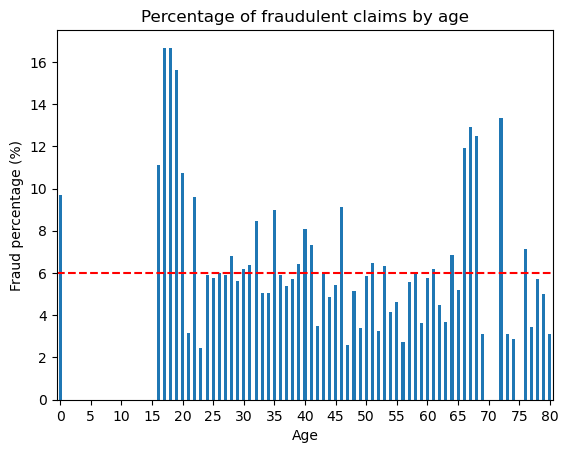

In [17]:
fraud_percentage_age.plot(kind="bar")

plt.xlabel("Age")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by age")

plt.xticks(
    ticks=range(0, 81, 5),
    labels=range(0, 81, 5),
    rotation=0
)

plt.axhline(y=6, linestyle="--", color="red")

plt.show()

Fraud is most frequently detected among teenagers and retired seniors. Teenagers have weak financial power as they have not yet started their economic activities, and retired seniors experience weakened financial power post-retirement. Considering these points, there seems to be a correlation between financial power and fraud.

Text(0.5, 1.0, 'Age distribution')

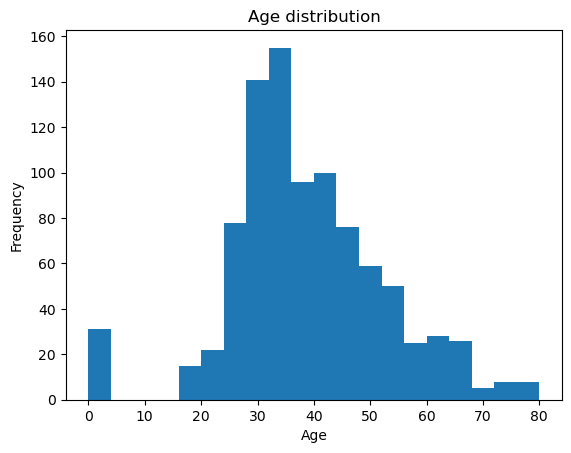

In [18]:
plt.hist(fraud["Age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age distribution")

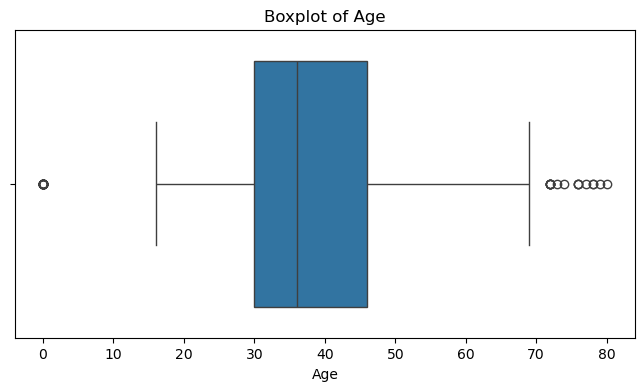

In [19]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=fraud["Age"])

plt.title("Boxplot of Age")
plt.show()

In [20]:
(fraud["Age"]==0).sum()

np.int64(31)

Many claims with "Age" = 0, we can't drop them. Since it is a numerical feature, we replace it with a measure of central tendency.
The median is more robust to outliers because extreme values have little effect on it.
The mean can be pulled up or down by extreme ages, making the imputed value less representative.

In [21]:
median_age = raw_data.Age[raw_data["Age"] != 0].median()
mean_age = raw_data.Age[raw_data["Age"] != 0].mean()
print(median_age)
print(mean_age)

39.0
40.700331125827816


In [22]:
clean_data_1.loc[clean_data_1["Age"] == 0, "Age"] = median_age

### Feature "Sex"

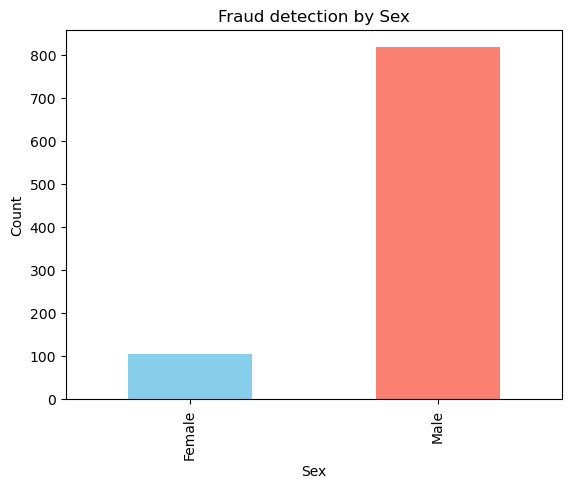

In [23]:
fraud["Sex"].value_counts().sort_values().plot(kind="bar", color=["skyblue", "salmon"])

plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Fraud detection by Sex")
plt.show()

These results suggest that males are significantly more likely to be involved in detected fraud cases compared to females. However, this should be interpreted with some caution, as there are also more male drivers than female drivers in the dataset. As a result, males generate a higher number of claims overall, which can naturally lead to a higher absolute number of detected fraud cases.

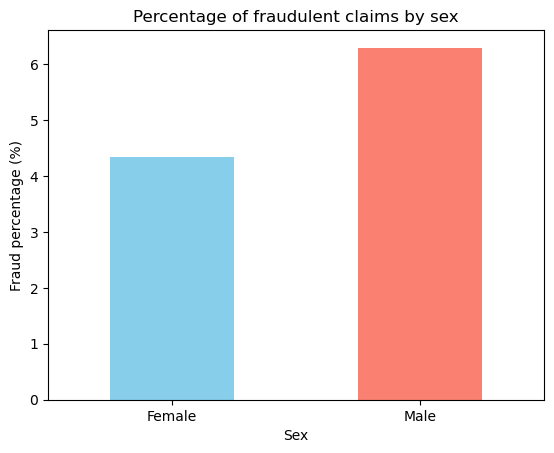

In [24]:
fraud_percentage_sex = (
    raw_data.groupby("Sex")["FraudFound_P"]
    .mean()
    .mul(100)
)
fraud_percentage_sex.plot(kind="bar", color=["skyblue", "salmon"])

plt.xlabel("Sex")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by sex")
plt.xticks(rotation=0)
plt.show()

After studying percentages , males have a higher fraud rate.

### Feature "Make"

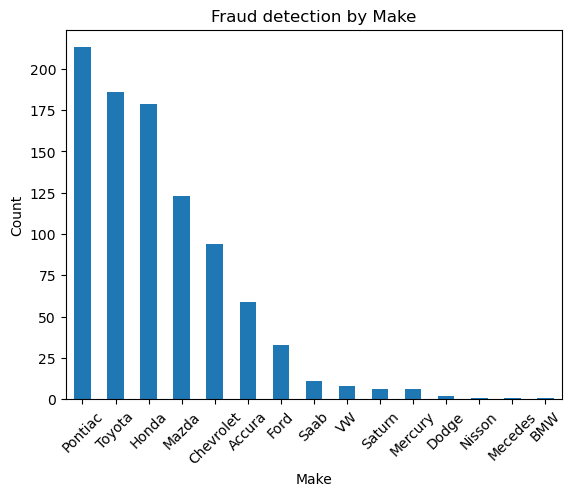

In [25]:
fraud["Make"].value_counts().plot(kind="bar")

plt.xlabel("Make")
plt.ylabel("Count")
plt.title("Fraud detection by Make")
plt.xticks(rotation=45)
plt.show()

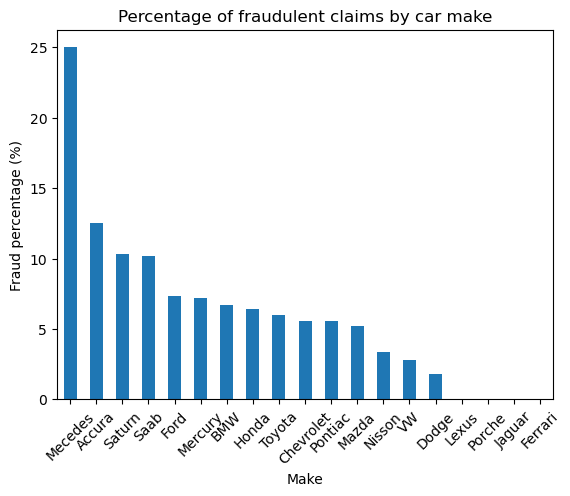

In [26]:
fraud_percentage_make = (
    raw_data.groupby("Make")["FraudFound_P"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fraud_percentage_make.plot(kind="bar")

plt.xlabel("Make")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by car make")
plt.xticks(rotation=45)
plt.show()

In [27]:
make_analysis = raw_data.groupby("Make").agg(
    Total_Claims=("FraudFound_P", "count"),
    Fraudulent_Claims=("FraudFound_P", "sum"),
    Fraud_Percentage=("FraudFound_P", "mean")
)

make_analysis["Fraud_Percentage"] *= 100

make_analysis.sort_values(
    "Fraud_Percentage",
    ascending=False
)

,Total_Claims,Fraudulent_Claims,Fraud_Percentage
Make,,,
Mecedes,4,1,25.000000
Accura,472,59,12.500000
Saturn,58,6,10.344828
Saab,108,11,10.185185
Ford,450,33,7.333333
Mercury,83,6,7.228916
BMW,15,1,6.666667
Honda,2801,179,6.390575
Toyota,3121,186,5.959628


For the Make variable, it is more informative to analyze the percentage of fraudulent claims within each car brand rather than only the absolute number of fraudulent claims. A brand may have a high number of fraud cases simply because it has a larger number of total claims. By calculating the fraud rate for each make, we can compare brands more fairly and identify whether certain car brands are associated with a higher proportion of fraudulent claims.

However, fraud percentages should be interpreted carefully when a car make has very few observations. For example, Mercedes shows a fraud rate of 25%, but this is based on only 4 total claims, with 1 fraudulent case. Because of this small sample size, the percentage is not very reliable and may exaggerate the apparent fraud risk compared with brands that have a much larger number of claims.

On the other hand, the Porche, Lexus, Jaguar, Ferrari owners have never been reported for fraud; all the four make are "High-End"

### Chi-square tests
Tests the independence of two categorical variables by comparing observed frequencies to expected frequencies.

- The chi-square test is a statistical test used to **determine whether there is a significant association between two categorical variables**.
- Interpretation: if p-value < 0.05, this suggests that there is a significant association between the categorical variables. P-value >= 0.05, indicates that there is not enough evidence to conclude a significant association between the variables.


In [28]:
from scipy.stats import chi2_contingency
crosstab_result = pd.crosstab(raw_data.PolicyType,raw_data.BasePolicy)
crosstab_result

BasePolicy,All Perils,Collision,Liability
PolicyType,,,
Sedan - All Perils,4087,0,0
Sedan - Collision,0,5584,0
Sedan - Liability,0,0,4987
Sport - All Perils,22,0,0
Sport - Collision,0,348,0
Sport - Liability,0,0,1
Utility - All Perils,340,0,0
Utility - Collision,0,30,0
Utility - Liability,0,0,21


In [29]:
_, chi2_pvalue, _, _  = chi2_contingency(crosstab_result)
a,b,c,d=chi2_contingency(crosstab_result)
float(chi2_pvalue)

0.0

In [30]:
float(chi2_pvalue) < 0.05

True

p-value< 0.05, we reject the hyphoteshis that the two categorical features are independet, this implies that there's a significant association between PolicyType and BasePolicy. we do have correlation between them

### Cramér's V

While the Chi-square test informs us about the independence of two categorical variables, Cramér's V measures the strength of the association between them.

- Cramer's V is a measure of association used to **quantify the strength of the relationship between categorical variables**.
- Interpretation: Cramer's V ranges from 0 to 1, where **0 indicates no association, and 1 represents a perfect association between the variables**. A higher value of Cramer's V indicates a stronger relationship between the categorical variables.


In [31]:
from scipy.stats.contingency import association
# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method='cramer')

0.9999999999999999

### Cramér’s V Interpretation Guide (Cohen's Conventions)

| Cramér’s V | Strength of Association   |
|------------|----------------------------|
| 0.00–0.10  | Negligible / Very Weak     |
| 0.10–0.20  | Weak                       |
| 0.20–0.30  | Moderate                   |
| 0.30–0.50  | Strong                     |
| > 0.50     | Very Strong                |


Very strong relationship between them. Final decision, to drop PolicyType.

In [32]:
clean_data_1.drop(columns=["PolicyType"], inplace=True)

In [33]:
clean_data_1.head()

,Month,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,...,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,Honda,Urban,Female,Single,21,Policy Holder,Sport,more than 69000,0,...,none,3 years,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,Honda,Urban,Male,Single,34,Policy Holder,Sport,more than 69000,0,...,none,6 years,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,Honda,Urban,Male,Married,47,Policy Holder,Sport,more than 69000,0,...,1,7 years,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,Toyota,Rural,Male,Married,65,Third Party,Sport,20000 to 29000,0,...,1,more than 7,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,Honda,Urban,Female,Single,27,Third Party,Sport,more than 69000,0,...,none,5 years,No,No,External,none,no change,1 vehicle,1994,Collision


Days_Policy_Accident vs Days_Policy_Claim

In [34]:
clean_data_1.Days_Policy_Claim.value_counts()

Days_Policy_Claim
more than 30    15342
15 to 30           56
8 to 15            21
none                1
Name: count, dtype: int64

In [35]:
clean_data_1.Days_Policy_Accident.value_counts()

Days_Policy_Accident
more than 30    15247
none               55
8 to 15            55
15 to 30           49
1 to 7             14
Name: count, dtype: int64

In [36]:
crosstab_result2 = pd.crosstab(clean_data_1.Days_Policy_Accident,clean_data_1.Days_Policy_Claim)
_, chi2_pvalue, _, _  = chi2_contingency(crosstab_result2)
a,b,c,d=chi2_contingency(crosstab_result2)
float(chi2_pvalue)

0.0

In [37]:
association(crosstab_result2, method='cramer')

0.4073286752092501

Although Days_Policy_Accident and Days_Policy_Claim are strongly related, we should not automatically drop either variable because they represent different stages of the insurance claim process. Days_Policy_Accident measures the time between policy inception and the accident, while Days_Policy_Claim measures the time between policy inception and the claim being reported. From a fraud detection perspective, both can contain useful information, since an accident occurring shortly after policy inception and a delayed claim submission may indicate different types of suspicious behavior. Therefore, even with a strong relationship between them, keeping both variables can preserve potentially relevant predictive information for the model.

# Data preprocessing

Label Encoding

In [38]:
binary_columns = [col for col in clean_data_1.columns if clean_data_1[col].nunique() == 2 and col != 'FraudFound_P']
binary_columns

['AccidentArea',
 'Sex',
 'Fault',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType']

In [39]:
le = LabelEncoder()

for col  in binary_columns:
    clean_data_1[col] = le.fit_transform(clean_data_1[col])
    print('Label Mapping: ', dict(zip(le.classes_, le.transform(le.classes_))))

Label Mapping:  {'Rural': np.int64(0), 'Urban': np.int64(1)}
Label Mapping:  {'Female': np.int64(0), 'Male': np.int64(1)}
Label Mapping:  {'Policy Holder': np.int64(0), 'Third Party': np.int64(1)}
Label Mapping:  {'No': np.int64(0), 'Yes': np.int64(1)}
Label Mapping:  {'No': np.int64(0), 'Yes': np.int64(1)}
Label Mapping:  {'External': np.int64(0), 'Internal': np.int64(1)}


In [40]:
vehicleprice_label = {'less than 20000': 0, '20000 to 29000': 1,  '30000 to 39000': 2, '40000 to 59000': 3, '60000 to 69000': 4, 'more than 69000': 5}
ageofvehicle_label = {'new': 0, '2 years': 1, '3 years': 2, '4 years': 3, '5 years': 4, '6 years': 5, '7 years': 6, 'more than 7': 7}
dayspolacc_label = {'none': 0, '1 to 7': 1, '8 to 15': 2, '15 to 30': 3, 'more than 30': 4}
dayspolcla_label = {'none': 0, '8 to 15': 2, '15 to 30': 3, 'more than 30': 4}
month_label = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
pastnumcla_label = {'none': 0, '1': 1, '2 to 4': 2, 'more than 4': 3}
numberofsup_label = {'none': 0, '1 to 2': 1, '3 to 5': 2, 'more than 5': 3}
addresschange_label = {'no change': 0, 'under 6 months': 1, '1 year': 2, '2 to 3 years': 3, '4 to 8 years': 4}
numberofcars_label = {'1 vehicle': 0, '2 vehicles': 1, '3 to 4': 2, '5 to 8': 3, 'more than 8': 4}

In [41]:
columns_labels = {
    'VehiclePrice': vehicleprice_label,
    'AgeOfVehicle': ageofvehicle_label,
    'Days_Policy_Accident': dayspolacc_label,
    'Days_Policy_Claim': dayspolcla_label,
    'Month': month_label,
    'PastNumberOfClaims': pastnumcla_label,
    'NumberOfSuppliments': numberofsup_label,
    'AddressChange_Claim': addresschange_label,
    'NumberOfCars': numberofcars_label
}

for column, label_map in columns_labels.items():
    clean_data_1[column] = clean_data_1[column].map(label_map)


One hot encoding

In [42]:
clean_data_1.columns

Index(['Month', 'Make', 'AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [43]:
clean_data_2 = pd.get_dummies(clean_data_1, columns=["Make","MaritalStatus","VehicleCategory","BasePolicy"], drop_first=True)

In [44]:
clean_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Month                    15420 non-null  int64
 1   AccidentArea             15420 non-null  int64
 2   Sex                      15420 non-null  int64
 3   Age                      15420 non-null  int64
 4   Fault                    15420 non-null  int64
 5   VehiclePrice             15420 non-null  int64
 6   FraudFound_P             15420 non-null  int64
 7   RepNumber                15420 non-null  int64
 8   Deductible               15420 non-null  int64
 9   DriverRating             15420 non-null  int64
 10  Days_Policy_Accident     15420 non-null  int64
 11  Days_Policy_Claim        15420 non-null  int64
 12  PastNumberOfClaims       15420 non-null  int64
 13  AgeOfVehicle             15420 non-null  int64
 14  PoliceReportFiled        15420 non-null  int64
 15  Wi

### Target Balance

In [45]:
target_count = raw_data.FraudFound_P.value_counts().reset_index()
target_count.columns = ["FraudFound_P", "Count"]
target_count

,FraudFound_P,Count
0,0,14497
1,1,923


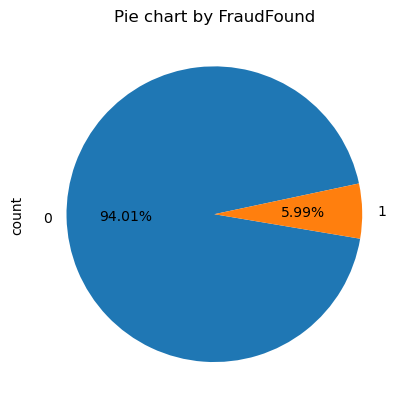

In [46]:
fraud_freq = raw_data.FraudFound_P.value_counts()
fraud_freq.plot.pie(autopct='%1.2f%%' ,startangle=12)
plt.title("Pie chart by FraudFound")
plt.show()

The Target Variable "Fraud_Found_P" is highly imbalanced

Issues Caused by Imbalanced Target Variable

Model Bias: The model may become biased towards the majority class, leading to poor performance on the minority class.

Misleading Metrics: Metrics like accuracy can be misleading, as high accuracy can be achieved by simply predicting the majority class.

Solutions: 
- use precision-recall and f1 score metrics.
  In this imbalanced dataset, we will use **recall and precision** as our main evaluation metrics, with a stronger focus on **recall**. In our case, a false negative for a fraudulent claim is more costly than a false positive. In other words, if the model predicts that a claim is not fraudulent when it actually is, the financial impact can be significant. This is more critical than incorrectly flagging a legitimate claim as fraudulent, which would mainly require further investigation.

- balance the dataset random undersampling.


# Modeling, Prediction and Evaluation

Models:

- Logistic regression
- KNN Clasiffier
- Random forest
- Gradient Boosting
- Xgboost
- LightGBM

In [47]:
X = clean_data_2._get_numeric_data().drop('FraudFound_P', axis=1)
y = clean_data_2.FraudFound_P

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

1. DEFAULT()

In [93]:
results1 = []
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(),
    "LightGBM": lgb.LGBMClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_train = model.predict(X_train)
    test_recall = round(recall_score(y_test, preds),2)
    train_recall = round(recall_score(y_train, preds_train),2)
    precision_sc = round(precision_score(y_test, preds),2)
    f1_sc = round(f1_score(y_test, preds),2)

    results1.append({
        'model': name,
        'test recall': test_recall,
        'train recall': train_recall,
        'precision': precision_sc,
        'f1 score': f1_sc
    })

    print(f"\n{name}:\n")
    print(confusion_matrix(y_test, preds))
    #print(classification_report(y_test, preds))
    print(f"Test Recall: {test_recall}")
    print(f"Train Recall: {train_recall}")
    print(f"Precision: {precision_sc}")
    print(f"F1 Score: {f1_sc}")

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Logistic Regression:

[[2899    0]
 [ 185    0]]
Test Recall: 0.0
Train Recall: 0.0
Precision: 0.0
F1 Score: 0.0

KNN:

[[2881   18]
 [ 180    5]]
Test Recall: 0.03
Train Recall: 0.06
Precision: 0.22
F1 Score: 0.05

Random Forest:

[[2896    3]
 [ 179    6]]
Test Recall: 0.03
Train Recall: 1.0
Precision: 0.67
F1 Score: 0.06

GradientBoosting:

[[2898    1]
 [ 178    7]]
Test Recall: 0.04
Train Recall: 0.06
Precision: 0.88
F1 Score: 0.07

XGBoost:

[[2881   18]
 [ 166   19]]
Test Recall: 0.1
Train Recall: 0.62
Precision: 0.51
F1 Score: 0.17

LightGBM:

[[2896    3]
 [ 177    8]]
Test Recall: 0.04
Train Recall: 0.23
Precision: 0.73
F1 Score: 0.08


In [201]:
order = [
    "Logistic Regression",
    "LightGBM",
    "Random Forest",
    "XGBoost",
    "KNN",
    "GradientBoosting"
]

results_df = pd.DataFrame(results1)

results_df["model"] = pd.Categorical(
    results_df["model"],
    categories=order,
    ordered=True
)

results_df = results_df.sort_values("model").reset_index(drop=True)
results_df

,model,test recall,train recall,precision,f1 score
0,Logistic Regression,0.00,0.00,0.00,0.00
1,LightGBM,0.04,0.23,0.73,0.08
2,Random Forest,0.03,1.00,0.67,0.06
3,XGBoost,0.10,0.62,0.51,0.17
4,KNN,0.03,0.06,0.22,0.05
5,GradientBoosting,0.04,0.06,0.88,0.07


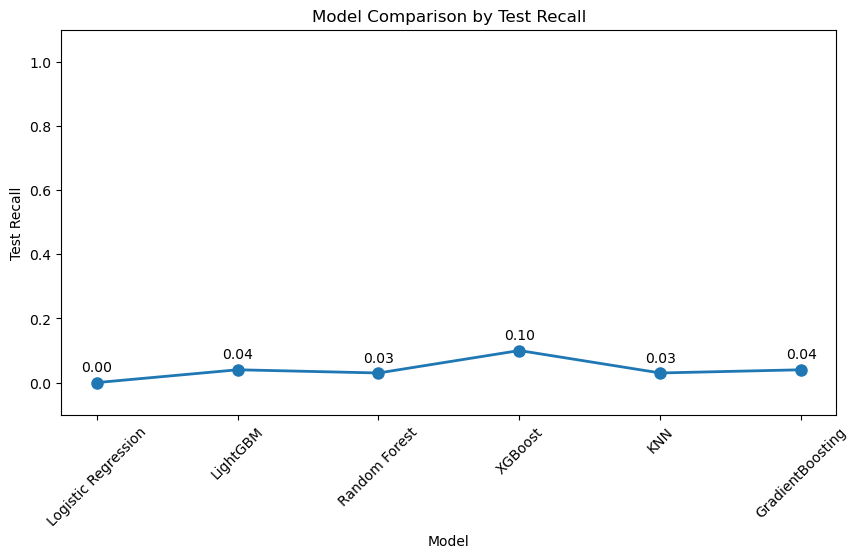

In [138]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["model"],
    results_df["test recall"],
    marker="o",
    markersize=8,
    linewidth=2
)

for model, recall in zip(results_df["model"], results_df["test recall"]):
    plt.annotate(
        f"{recall:.2f}",
        (model, recall),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.xlabel("Model")
plt.ylabel("Test Recall")
plt.title("Model Comparison by Test Recall")
plt.xticks(rotation=45)
plt.ylim(-0.1, 1.1)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.show()

2. HYPERPARAMETER + CLASS WEIGHT

In [139]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
results2 = []

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=13,
        #C=3,
        class_weight= "balanced"
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=3,
        n_jobs= -1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        criterion= "entropy", #log_lossentropy
        max_depth=10,
        max_features='log2',
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=13,
        class_weight= "balanced"
    ),
    "GradientBoosting": GradientBoostingClassifier(
        #loss= "exponential",#default es log_loss
        learning_rate=0.05,
        n_estimators=200,
        #criterion= "friedman_mse",
        random_state=13,
        max_features=5
    ),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', scale_pos_weight=scale),
    "LightGBM": lgb.LGBMClassifier(
        num_leaves=35,
        learning_rate=0.05,
        n_estimators=100,
        random_state=13,
        verbose=-1,
        class_weight="balanced"
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_train = model.predict(X_train)
    test_recall = round(recall_score(y_test, preds),2)
    train_recall = round(recall_score(y_train, preds_train),2)
    precision_sc = round(precision_score(y_test, preds),2)
    f1_sc = round(f1_score(y_test, preds),2)
    
    results2.append({
        'model': name,
        'test recall': test_recall,
        'train recall': train_recall,
        'precision': precision_sc,
        'f1 score': f1_sc
    })
    
    print(f"\n{name}:\n")
    print(confusion_matrix(y_test, preds))
    #print(classification_report(y_test, preds))
    print(f"Test Recall: {test_recall}")
    print(f"Train Recall: {train_recall}")
    print(f"Precision: {precision_sc}")
    print(f"F1 Score: {f1_sc}")

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression:

[[1763 1136]
 [  15  170]]
Test Recall: 0.92
Train Recall: 0.9
Precision: 0.13
F1 Score: 0.23

KNN:

[[2859   40]
 [ 173   12]]
Test Recall: 0.06
Train Recall: 0.18
Precision: 0.23
F1 Score: 0.1

Random Forest:

[[1976  923]
 [  33  152]]
Test Recall: 0.82
Train Recall: 0.96
Precision: 0.14
F1 Score: 0.24


c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



GradientBoosting:

[[2899    0]
 [ 185    0]]
Test Recall: 0.0
Train Recall: 0.01
Precision: 0.0
F1 Score: 0.0

XGBoost:

[[2624  275]
 [  96   89]]
Test Recall: 0.48
Train Recall: 1.0
Precision: 0.24
F1 Score: 0.32

LightGBM:

[[2154  745]
 [  27  158]]
Test Recall: 0.85
Train Recall: 1.0
Precision: 0.17
F1 Score: 0.29


In [202]:
results_df = pd.DataFrame(results2)

results_df["model"] = pd.Categorical(
    results_df["model"],
    categories=order,
    ordered=True
)

results_df = results_df.sort_values("model").reset_index(drop=True)
results_df

,model,test recall,train recall,precision,f1 score
0,Logistic Regression,0.92,0.90,0.13,0.23
1,LightGBM,0.85,1.00,0.17,0.29
2,Random Forest,0.82,0.96,0.14,0.24
3,XGBoost,0.48,1.00,0.24,0.32
4,KNN,0.06,0.18,0.23,0.10
5,GradientBoosting,0.00,0.01,0.00,0.00


In [141]:
#results_df = pd.DataFrame(results2).sort_values(by="test recall", ascending=False).reset_index(drop=True)
#results_df

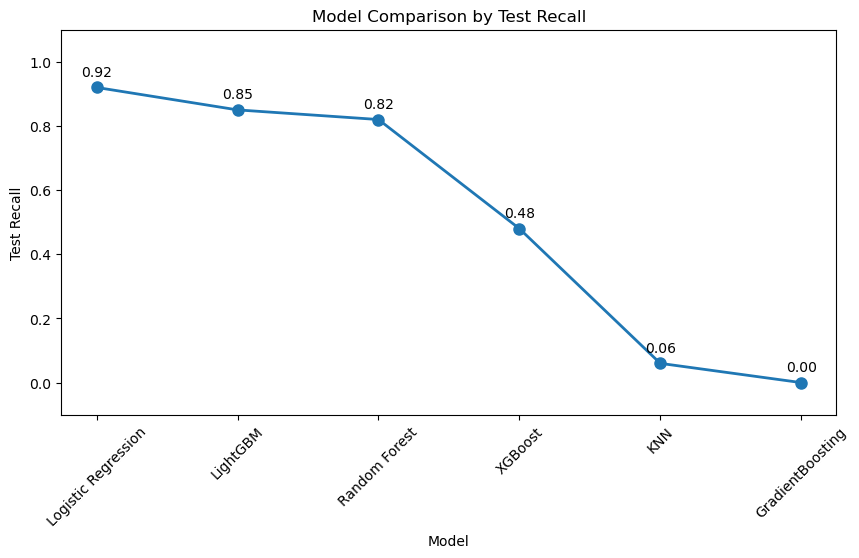

In [142]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["model"],
    results_df["test recall"],
    marker="o",
    markersize=8,
    linewidth=2
)

for model, recall in zip(results_df["model"], results_df["test recall"]):
    plt.annotate(
        f"{recall:.2f}",
        (model, recall),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.xlabel("Model")
plt.ylabel("Test Recall")
plt.title("Model Comparison by Test Recall")
plt.xticks(rotation=45)
plt.ylim(-0.1, 1.1)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.show()

3. Randomized search CROSS VALIDATION

Random forest

In [ ]:
# Define the model
rf = RandomForestClassifier(random_state=13,class_weight="balanced")

# Define parameter grid for tuning
param_dist = {
    'n_estimators': [100, 200, 500],   # number of trees
    'max_depth': [None, 10, 20],       # tree depth
    'min_samples_split': [2, 5, 10],   # min samples to split
    'min_samples_leaf': [1, 2, 4],      # min samples per leaf
    'max_features': [None, "log2"]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_rf = random_search.best_estimator_

# Evaluate on test set
y_pred = best_rf.predict(X_test)
preds_train = best_rf.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
Test Recall: 0.81
Train Recall: 0.96


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}

Test Recall: 0.81

Train Recall: 0.96

time: 4m 23s

we take this best parameters and do a second randomizedsearch cv around these parameters.

In [ ]:
# Define the model
rf = RandomForestClassifier(random_state=13,class_weight="balanced")

# Define parameter grid for tuning
param_dist = {
    'n_estimators': [150, 200, 250],   # number of trees
    'max_depth': [5, 10, 15],       # tree depth
    'min_samples_split': [10, 15, 20],   # min samples to split
    'min_samples_leaf': [1, 2, 3],      # min samples per leaf
    'max_features': ["sqrt", "log2"]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_rf = random_search.best_estimator_

# Evaluate on test set
y_pred = best_rf.predict(X_test)
preds_train = best_rf.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'n_estimators': 250, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}
Test Recall: 0.96
Train Recall: 0.96


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'n_estimators': 250, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}

Test Recall: 0.96

Train Recall: 0.96

time: 1m 28s

we take this best parameters and do a third randomizedsearch cv around these parameters.

In [ ]:
# Define the model
rf = RandomForestClassifier(random_state=13,class_weight="balanced")

# Define parameter grid for tuning
param_dist = {
    'n_estimators': [240, 250, 260, 270],   # number of trees
    'max_depth': [5, 8, 10, 12],       # tree depth
    'min_samples_split': [14, 15, 16],   # min samples to split
    'min_samples_leaf': [1, 2],      # min samples per leaf
    'max_features': ["log2"]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_rf = random_search.best_estimator_

# Evaluate on test set
y_pred = best_rf.predict(X_test)
preds_train = best_rf.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'n_estimators': 270, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}
Test Recall: 0.96
Train Recall: 0.96


Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters: {'n_estimators': 270, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}

Test Recall: 0.96

Train Recall: 0.96

time 2m 22s

one more and last

In [203]:
# Define the model
rf = RandomForestClassifier(random_state=13,class_weight="balanced")

# Define parameter grid for tuning
param_dist = {
    'n_estimators': [290, 300, 310],   # number of trees
    'max_depth': [4,5,6],       # tree depth
    'min_samples_split': [13, 14, 15],   # min samples to split
    'min_samples_leaf': [2],      # min samples per leaf
    'max_features': ["log2"]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_rf = random_search.best_estimator_

# Evaluate on test set
y_pred = best_rf.predict(X_test)
preds_train = best_rf.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
precision_sc = round(precision_score(y_test, preds),2)
f1_sc = round(f1_score(y_test, preds),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")
print(f"Precision: {precision_sc}")
print(f"F1 score: {f1_sc}")

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 27 is smaller than n_iter=30. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'n_estimators': 290, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 4}
Test Recall: 0.96
Train Recall: 0.96
Precision: 0.17
F1 score: 0.29


In [204]:
results3 = results2.copy()

In [205]:
new_result = {
    "model": "Random Forest",
    "test recall": test_recall,
    "train recall": train_recall,
    "precision": precision_sc,
    "f1 score": f1_sc
}

for i, result in enumerate(results3):
    if result["model"] == new_result["model"]:
        results3[i] = new_result
        break
else:
    results3.append(new_result)

results_df = pd.DataFrame(results3)

results_df["model"] = pd.Categorical(
    results_df["model"],
    categories=order,
    ordered=True
)
results_df = results_df.sort_values("model").reset_index(drop=True)
results_df

,model,test recall,train recall,precision,f1 score
0,Logistic Regression,0.92,0.90,0.13,0.23
1,LightGBM,0.85,1.00,0.17,0.29
2,Random Forest,0.96,0.96,0.17,0.29
3,XGBoost,0.48,1.00,0.24,0.32
4,KNN,0.06,0.18,0.23,0.10
5,GradientBoosting,0.00,0.01,0.00,0.00


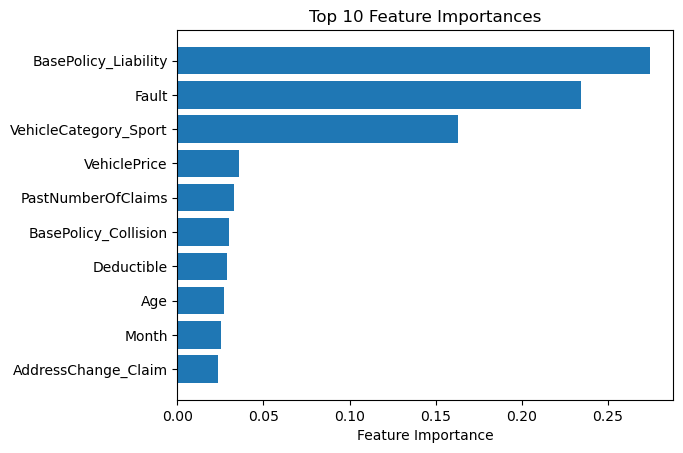

In [206]:
sort_idx = best_rf.feature_importances_.argsort()[-10:]
plt.barh(X.columns[sort_idx],best_rf.feature_importances_[sort_idx])
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances")
plt.show()

LOGISTIC REGRESSION

In [209]:
# Define the model
lr = LogisticRegression(max_iter=1000,random_state=13)

# Define parameter grid for tuning
param_dist = {
    'C': [0.01,0.1,1,5,10],
    'penalty': ["l1","l2"],   
    'solver': ["liblinear"],
    'class_weight': ["balanced"]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_lr = random_search.best_estimator_

# Evaluate on test set
y_pred = best_lr.predict(X_test)
preds_train = best_lr.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
precision_sc = round(precision_score(y_test, preds),2)
f1_sc = round(f1_score(y_test, preds),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")
print(f"Precision: {precision_sc}")
print(f"F1 score: {f1_sc}")

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=30. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.01}
Test Recall: 0.94
Train Recall: 0.92
Precision: 0.17
F1 score: 0.29


In [211]:
# Define the model
lr = LogisticRegression(max_iter=1000, random_state=13)

# Define parameter grid for tuning
param_dist = {
    'C': [0.01,0.02],
    'penalty': ["l1"],   
    'solver': ["liblinear"],
    'class_weight': ["balanced"]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_lr = random_search.best_estimator_

# Evaluate on test set
y_pred = best_lr.predict(X_test)
preds_train = best_lr.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
precision_sc = round(precision_score(y_test, preds),2)
f1_sc = round(f1_score(y_test, preds),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")
print(f"Precision: {precision_sc}")
print(f"F1 score: {f1_sc}")

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=30. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.01}
Test Recall: 0.94
Train Recall: 0.92
Precision: 0.17
F1 score: 0.29


In [212]:
new_result = {
    "model": "Logistic Regression",
    "test recall": test_recall,
    "train recall": train_recall,
    "precision": precision_sc,
    "f1 score": f1_sc
}

for i, result in enumerate(results3):
    if result["model"] == new_result["model"]:
        results3[i] = new_result
        break
else:
    results3.append(new_result)

results_df = pd.DataFrame(results3)

results_df["model"] = pd.Categorical(
    results_df["model"],
    categories=order,
    ordered=True
)
results_df = results_df.sort_values("model").reset_index(drop=True)
results_df

,model,test recall,train recall,precision,f1 score
0,Logistic Regression,0.94,0.92,0.17,0.29
1,LightGBM,0.85,1.00,0.17,0.29
2,Random Forest,0.96,0.96,0.17,0.29
3,XGBoost,0.48,1.00,0.24,0.32
4,KNN,0.06,0.18,0.23,0.10
5,GradientBoosting,0.00,0.01,0.00,0.00


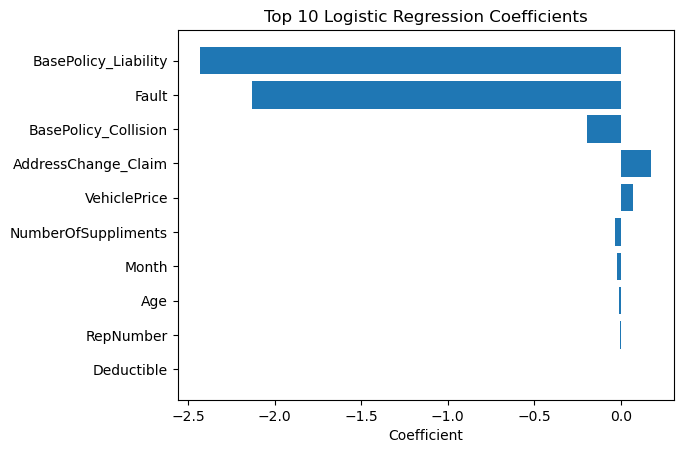

In [213]:
coef = best_lr.coef_[0]
sort_idx = np.argsort(np.abs(coef))[-10:]

plt.barh(
    X.columns[sort_idx],
    coef[sort_idx]
)

plt.xlabel("Coefficient")
plt.title("Top 10 Logistic Regression Coefficients")
plt.show()

LIGHTGBM

In [190]:
# Define the model
lgbclass = lgb.LGBMClassifier(random_state=13,class_weight="balanced")

# Define parameter grid for tuning
param_dist = {
    'num_leaves': [15,35,50],
    'max_depth': [-1,5,10],   
    'learning_rate': [0.01,0.05,0.1],
    'n_estimators': [100,200],
    'min_child_samples': [10,20,30],
    'subsample': [0.8,1]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lgbclass,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_lgb = random_search.best_estimator_

# Evaluate on test set
y_pred = best_lgb.predict(X_test)
preds_train = best_lgb.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
precision_sc = round(precision_score(y_test, preds),2)
f1_sc = round(f1_score(y_test, preds),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")
print(f"Precision: {precision_sc}")
print(f"F1 score: {f1_sc}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.01}
Test Recall: 0.93
Train Recall: 0.96
Precision: 0.17
F1 score: 0.29


In [214]:
# Define the model
lgbclass = lgb.LGBMClassifier(random_state=13,class_weight="balanced")

# Define parameter grid for tuning
param_dist = {
    'num_leaves': [55,60,80],
    'max_depth': [2,4,5],   
    'learning_rate': [0.01],
    'n_estimators': [60,70,80],
    'min_child_samples': [25,30,35],
    'subsample': [0.5,0.7]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lgbclass,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_lgb = random_search.best_estimator_

# Evaluate on test set
y_pred = best_lgb.predict(X_test)
preds_train = best_lgb.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
precision_sc = round(precision_score(y_test, preds),2)
f1_sc = round(f1_score(y_test, preds),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")
print(f"Precision: {precision_sc}")
print(f"F1 score: {f1_sc}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.5, 'num_leaves': 60, 'n_estimators': 60, 'min_child_samples': 35, 'max_depth': 4, 'learning_rate': 0.01}
Test Recall: 0.96
Train Recall: 0.96
Precision: 0.17
F1 score: 0.29


In [222]:
print(recall_score(y_test, y_pred))

0.9567567567567568


In [215]:
new_result = {
    "model": "LightGBM",
    "test recall": test_recall,
    "train recall": train_recall,
    "precision": precision_sc,
    "f1 score": f1_sc
}

for i, result in enumerate(results3):
    if result["model"] == new_result["model"]:
        results3[i] = new_result
        break
else:
    results3.append(new_result)

results_df = pd.DataFrame(results3)

results_df["model"] = pd.Categorical(
    results_df["model"],
    categories=order,
    ordered=True
)
results_df = results_df.sort_values("model").reset_index(drop=True)
results_df

,model,test recall,train recall,precision,f1 score
0,Logistic Regression,0.94,0.92,0.17,0.29
1,LightGBM,0.96,0.96,0.17,0.29
2,Random Forest,0.96,0.96,0.17,0.29
3,XGBoost,0.48,1.00,0.24,0.32
4,KNN,0.06,0.18,0.23,0.10
5,GradientBoosting,0.00,0.01,0.00,0.00


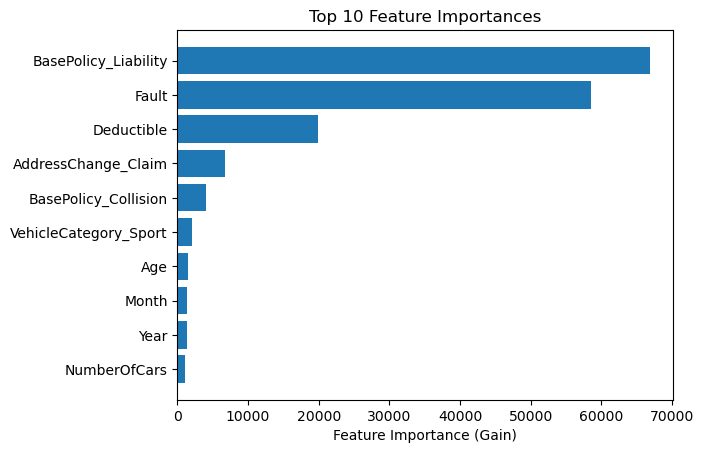

In [220]:
importance = best_lgb.booster_.feature_importance(importance_type="gain")
sort_idx = importance.argsort()[-10:]

plt.barh(X.columns[sort_idx],importance[sort_idx])

plt.xlabel("Feature Importance (Gain)")
plt.title("Top 10 Feature Importances")
plt.show()

Most important features:
- BasePolicy
- Fault
- VehicleCategory
- AddressChange_Claim
- VehiclePrice

we will see after scaling, if these importances change in lr

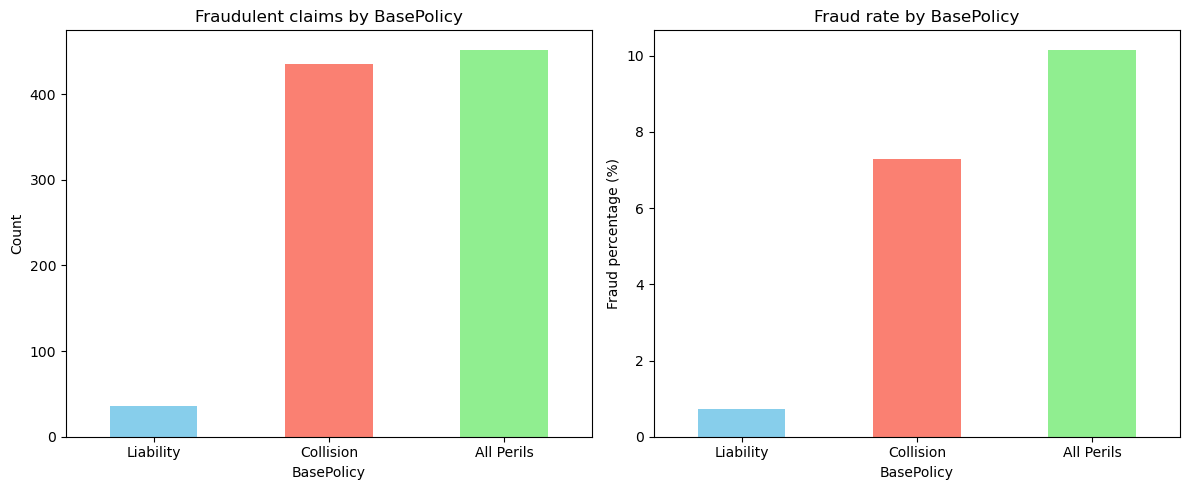

In [ ]:
order_feature1 = ["Liability", "Collision", "All Perils"]

colors = {
    "Liability": "skyblue",
    "Collision": "salmon",
    "All Perils": "lightgreen"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Number of fraudulent claims
fraud_counts = (
    fraud["BasePolicy"]
    .value_counts()
    .reindex(order_feature1)
)

fraud_counts.plot(
    kind="bar",
    ax=axes[0],
    color=[colors[x] for x in fraud_counts.index]
)

axes[0].set_xlabel("BasePolicy")
axes[0].set_ylabel("Count")
axes[0].set_title("Fraudulent claims by BasePolicy")
axes[0].tick_params(axis="x", rotation=0)


# Chart 2: Fraud percentage
fraud_percentage_basepolicy = (
    raw_data.groupby("BasePolicy")["FraudFound_P"]
    .mean()
    .mul(100)
    .reindex(order_feature1)
)

fraud_percentage_basepolicy.plot(
    kind="bar",
    ax=axes[1],
    color=[colors[x] for x in fraud_percentage_basepolicy.index]
)

axes[1].set_xlabel("BasePolicy")
axes[1].set_ylabel("Fraud percentage (%)")
axes[1].set_title("Fraud rate by BasePolicy")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

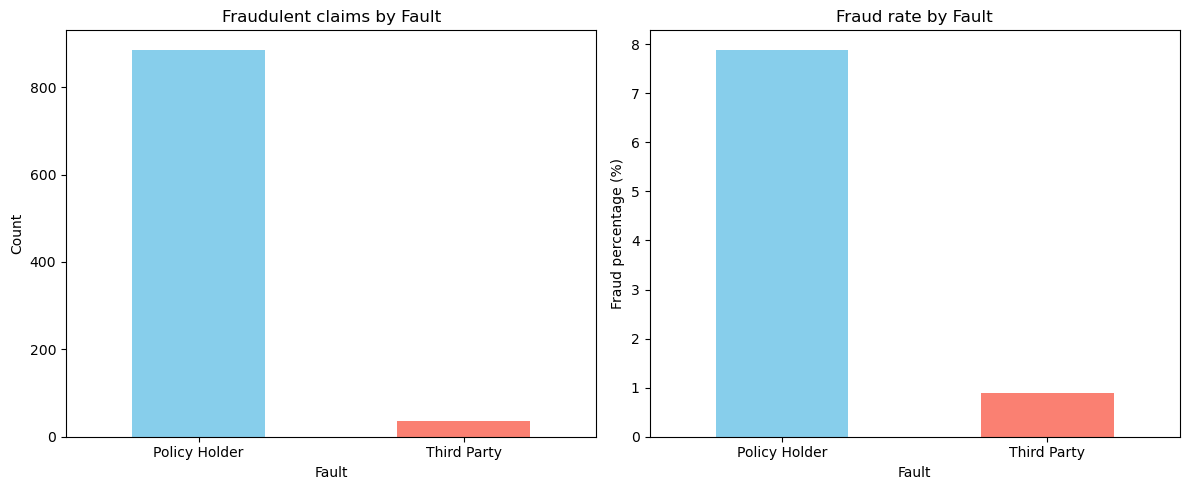

In [ ]:
order_feature2 = ["Policy Holder", "Third Party"]

colors = {
    "Policy Holder": "skyblue",
    "Third Party": "salmon"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Number of fraudulent claims
fraud_counts = (
    fraud["Fault"]
    .value_counts()
    .reindex(order_feature2)
)

fraud_counts.plot(
    kind="bar",
    ax=axes[0],
    color=[colors[x] for x in fraud_counts.index]
)

axes[0].set_xlabel("Fault")
axes[0].set_ylabel("Count")
axes[0].set_title("Fraudulent claims by Fault")
axes[0].tick_params(axis="x", rotation=0)


# Chart 2: Percentage of fraudulent claims
fraud_percentage_fault = (
    raw_data.groupby("Fault")["FraudFound_P"]
    .mean()
    .mul(100)
    .reindex(order_feature2)
)

fraud_percentage_fault.plot(
    kind="bar",
    ax=axes[1],
    color=[colors[x] for x in fraud_percentage_fault.index]
)

axes[1].set_xlabel("Fault")
axes[1].set_ylabel("Fraud percentage (%)")
axes[1].set_title("Fraud rate by Fault")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [177]:
raw_data.Fault.value_counts()

Fault
Policy Holder    11230
Third Party       4190
Name: count, dtype: int64

In [178]:
raw_data.BasePolicy.value_counts()

BasePolicy
Collision     5962
Liability     5009
All Perils    4449
Name: count, dtype: int64

In [181]:
fraud.AddressChange_Claim.value_counts()

AddressChange_Claim
no change         825
2 to 3 years       51
4 to 8 years       33
1 year             11
under 6 months      3
Name: count, dtype: int64

In [182]:
fraud.VehiclePrice.value_counts()

VehiclePrice
20000 to 29000     421
more than 69000    189
30000 to 39000     175
less than 20000    103
40000 to 59000      31
60000 to 69000       4
Name: count, dtype: int64

RESULTS 3


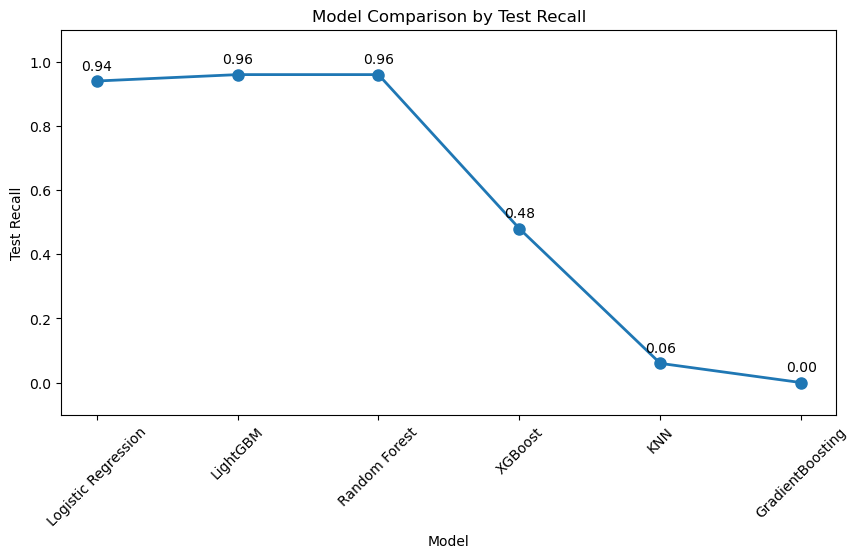

In [221]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["model"],
    results_df["test recall"],
    marker="o",
    markersize=8,
    linewidth=2
)

for model, recall in zip(results_df["model"], results_df["test recall"]):
    plt.annotate(
        f"{recall:.2f}",
        (model, recall),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.xlabel("Model")
plt.ylabel("Test Recall")
plt.title("Model Comparison by Test Recall")
plt.xticks(rotation=45)
plt.ylim(-0.1, 1.1)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.show()

comparison chart

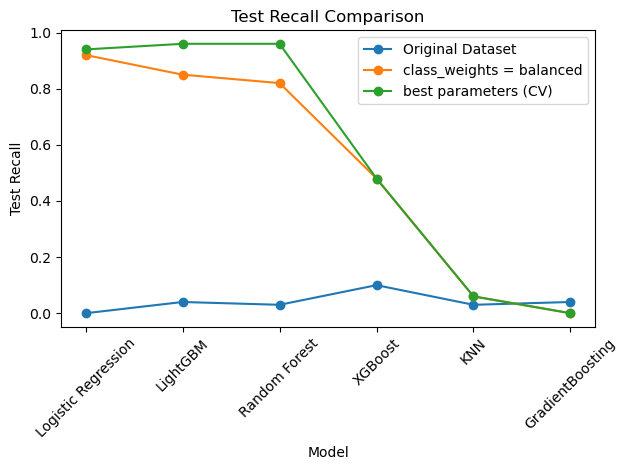

In [227]:
df1 = pd.DataFrame(results1)
df2 = pd.DataFrame(results2)
df3 = pd.DataFrame(results3)

df1 = df1.set_index("model").reindex(order).reset_index()
df2 = df2.set_index("model").reindex(order).reset_index()
df3 = df3.set_index("model").reindex(order).reset_index()

plt.plot(df1["model"], df1["test recall"], marker="o", label="Original Dataset")
plt.plot(df2["model"], df2["test recall"], marker="o", label="class_weights = balanced")
plt.plot(df3["model"], df3["test recall"], marker="o", label="best parameters (CV)")

plt.xlabel("Model")
plt.ylabel("Test Recall")
plt.title("Test Recall Comparison")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Already did hyperparameter finetuning, ensemble models, now we try scaling data for logistic regression

SCALING DATA

In [230]:
scaler = StandardScaler()

X_train[["Age","Deductible","Year"]] = scaler.fit_transform(X_train[["Age","Deductible","Year"]])
X_test[["Age","Deductible","Year"]] = scaler.transform(X_test[["Age","Deductible","Year"]])

In [233]:
# Define the model
lr = LogisticRegression(max_iter=1000, random_state=13)

# Define parameter grid for tuning
param_dist = {
    'C': [0.01,0.02],
    'penalty': ["l1"],   
    'solver': ["liblinear"],
    'class_weight': ["balanced"]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_lr = random_search.best_estimator_

# Evaluate on test set
y_pred = best_lr.predict(X_test)
preds_train = best_lr.predict(X_train)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
precision_sc = round(precision_score(y_test, preds),2)
f1_sc = round(f1_score(y_test, preds),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")
print(f"Precision: {precision_sc}")
print(f"F1 score: {f1_sc}")

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=30. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.01}
Test Recall: 0.94
Train Recall: 0.92
Precision: 0.17
F1 score: 0.29


In [234]:
new_result = {
    "model": "Logistic Regression",
    "test recall": test_recall,
    "train recall": train_recall,
    "precision": precision_sc,
    "f1 score": f1_sc
}

for i, result in enumerate(results3):
    if result["model"] == new_result["model"]:
        results3[i] = new_result
        break
else:
    results3.append(new_result)

results_df = pd.DataFrame(results3)

results_df["model"] = pd.Categorical(
    results_df["model"],
    categories=order,
    ordered=True
)
results_df = results_df.sort_values("model").reset_index(drop=True)
results_df

,model,test recall,train recall,precision,f1 score
0,Logistic Regression,0.94,0.92,0.17,0.29
1,LightGBM,0.96,0.96,0.17,0.29
2,Random Forest,0.96,0.96,0.17,0.29
3,XGBoost,0.48,1.00,0.24,0.32
4,KNN,0.06,0.18,0.23,0.10
5,GradientBoosting,0.00,0.01,0.00,0.00


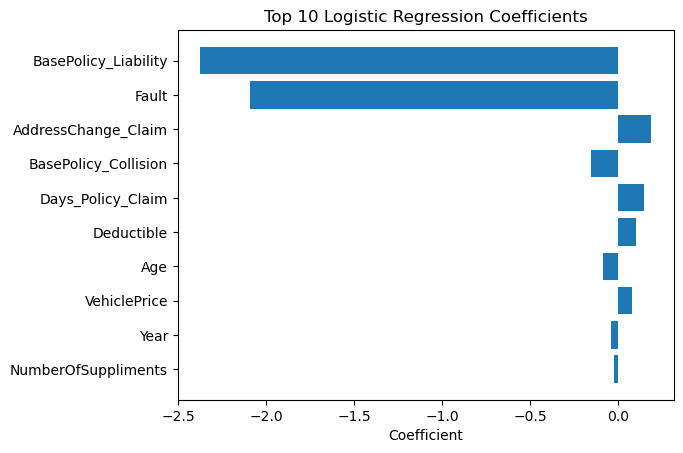

In [235]:
coef = best_lr.coef_[0]
sort_idx = np.argsort(np.abs(coef))[-10:]

plt.barh(
    X.columns[sort_idx],
    coef[sort_idx]
)

plt.xlabel("Coefficient")
plt.title("Top 10 Logistic Regression Coefficients")
plt.show()

There was almost no change scaling features.

FEATURE SELECTION - only most important features

In [240]:
X_train_top3 = X_train[["BasePolicy_Liability","Fault","VehicleCategory_Sport"]] #,"VehicleCategory_Sport","PastNumberOfClaims","VehiclePrice"
X_test_top3 = X_test[["BasePolicy_Liability","Fault","VehicleCategory_Sport"]] #,"VehicleCategory_Sport","PastNumberOfClaims","VehiclePrice"

In [242]:
# Define the model
rf = RandomForestClassifier(random_state=13,class_weight="balanced")

# Define parameter grid for tuning
param_dist = {
    'n_estimators': [290, 300, 310],   # number of trees
    'max_depth': [4,5,6],       # tree depth
    'min_samples_split': [13, 14, 15],   # min samples to split
    'min_samples_leaf': [2],      # min samples per leaf
    'max_features': ["log2"]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='recall',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
)

# Fit randomized search
random_search.fit(X_train_top3, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_rf = random_search.best_estimator_

# Evaluate on test set
y_pred = best_rf.predict(X_test_top3)
preds_train = best_rf.predict(X_train_top3)
test_recall = round(recall_score(y_test, y_pred),2)
train_recall = round(recall_score(y_train, preds_train),2)
precision_sc = round(precision_score(y_test, preds),2)
f1_sc = round(f1_score(y_test, preds),2)
print(f"Test Recall: {test_recall}")
print(f"Train Recall: {train_recall}")
print(f"Precision: {precision_sc}")
print(f"F1 score: {f1_sc}")

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 27 is smaller than n_iter=30. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'n_estimators': 290, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 4}
Test Recall: 0.94
Train Recall: 0.92
Precision: 0.17
F1 score: 0.29


------------------------------------------

Economy Impact

In real life, cost calculations are more complex; here, we will simplify the calculation to make it easier to understand. in this business simulation we'll assume that each false positive in fraud detection costs the insurance company €10, due to the expert's or reviewer's working hour. 

On the other hand, a false negative—that is, a claim that was identified as non-fraudulent but is in fact fraudulent—costs €8,000, taking into account the hours spent at the repair shop, the mechanic’s labor, replacement parts, etc.

Now that we know the cost of the reviews (false positive) and the cost of a fraud (false negative), we make the decision of adjusting our model. To do this, we'll use our best model, the random forest.

At this point, I’d like to pause and mention that in the Spanish and European insurance industries, generalized linear models (GLM) are still widely used by many companies to calculate and estimate premiums and reserves. This is due to the strict regulations here in Europe. Some regulators still do not accept machine learning (ML), deep learning, or complex models because of their low interpretability; according to them, these models are difficult to understand, and the principle of prudence takes precedence. 

Thinking about other sectors, the same thing happened with privacy and the introduction of AI in Europe, which was eventually permitted.

Little by little, everything will tend to be permitted, since other countries—such as the United States, the UK, and countries in Asia—have already begun developing these complex models and are already one step ahead of us.

ok so, the default threshold the models use to determine whether or not it is fraud is 0.5. for example, if the probability is 0.6, thenis fraud, if prob is 0.3 is not fraud on default situation.

here depending on the costs we will determine and adjust the threshold to achieve the lowest expected cost.

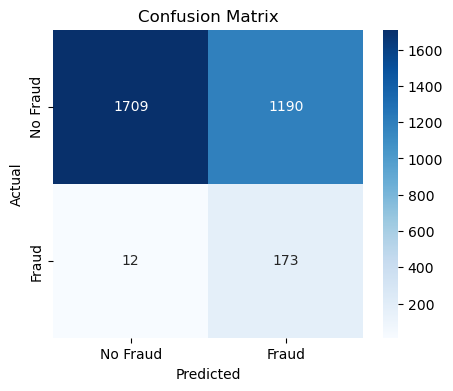

In [333]:
y_prob = best_rf.predict_proba(X_test_top3)[:, 1]
y_pred_thresh = (y_prob >= 0.2).astype(int)
cm = confusion_matrix(y_test, y_pred_thresh)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Fraud", "Fraud"], yticklabels=["No Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ConFUSION MATRIX + THRESHOLD


threshold = 0.2 -> 6 FN , 1474 FP   ->

threshold = 0.5 -> 12 FN , 1190 FP  ->

threshold = 0.6 -> 34 FN , 998 FP   ->

threshold = 0.7 -> 89 FN , 574 FP   ->

In [354]:
FN = 3000
FP = 300

In [355]:
6*FN + 1274*FP

400200

In [356]:
12*FN + 1190*FP

393000

In [357]:
34*FN + 998*FP

401400

In [358]:
89*FN + 574*FP

439200